# TKAN v3 — Model Training & Evaluation

**CAC 40 Total Return | 10-day log return**

This notebook covers model architecture, walk-forward training, training diagnostics, and the interactive prediction chart.  
Feature engineering and IC analysis live in **`feature_analysis.ipynb`**.

't just fit bac---

| Section | Content |
|---------|---------|
| 1. Setup | Imports and configuration |
| 2. Data & Features | Compact data load + build feature matrix X and target y |
| 3. Architecture & Training | `build_model()`, `train_cycle()`, walk-forward (skip-if-exists) |
| 4. Training Diagnostics | Per-cycle loss curves, convergence, overfit ratio |
| 5. Inference & Predictions | Load weights, pre-compute OOS prediction cache |
| 5b. Prediction Chart | Interactive slider with empirical ±2σ confidence bands |

---
| Version | Target | Instrument | Status |
|---------|--------|------------|--------|
| v2 | LVC.PA close price (EUR) | LVC.PA | ✅ trained |
| v3 | CAC 40 TR 10d log return | C40.PA / LVC.PA | 🔨 this notebook |

## 1. Setup & Configuration

In [ ]:
import os, json, pickle, warnings, pathlib, sys
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
from signum import Chart, Dashboard
import tensorflow as tf
from tkan import TKAN
from sklearn.preprocessing import RobustScaler
import plotly.io as pio
pio.renderers.default = 'notebook'

sys.path.insert(0, r"C:\Personal\Business & Investments\Python codes\sfera-db")
import sfera_db

# ── Paths ─────────────────────────────────────────────────────────────
try:
    _here = pathlib.Path(__vscode_ipynb_path__).parent
except NameError:
    _here = pathlib.Path(os.getcwd()) / 'research' / 'TacticalIndex' / 'tkan' / 'v3'

SCRIPT_DIR  = str(_here)
DATA_DIR    = str(_here / 'Data')
WEIGHTS_DIR = str(_here / 'weights')
OUTPUT_DIR  = str(_here / 'output')
SFERA_ENV   = str(_here.parents[6] / 'RU Market Data' / 'Python' / 'Sfera' / '.env')

for _d in (DATA_DIR, WEIGHTS_DIR, OUTPUT_DIR):
    os.makedirs(_d, exist_ok=True)

# ── Model config ──────────────────────────────────────────────────────
WINDOW_SIZE      = 30   # 30 days of context → richer temporal signal
PREDICTION_DAYS  = 5    # predict 5 signed daily log returns simultaneously
TARGET_TYPE      = 'path5d'   # 'path5d' = full forward path; included in fingerprint
BACKTEST_START   = '2015-01-01'
RETRAIN_FREQ     = 252
IVOL_EXIT_WINDOW = 126
DROPOUT_RATE     = 0.2
INITIAL_CAPITAL  = 100_000
MC_SAMPLES       = 50

INSTRUMENT_TICKER = 'C40.PA'
INSTRUMENT_LEV    = 'LVC.PA'

FEATURE_COLS = [
    'log_return_1d', 'high_low_range', 'close_to_high',
    'close_vs_sma15',
    'ivol_zscore', 'ivol_ema_ratio', 'ivol_pctl', 'ivol_roc5',
    'rvol_park20_zscore', 'vol_spread',
    'return_5d', 'return_20d',
]

print(f'Weights  → {WEIGHTS_DIR}')
print(f'Target   → {PREDICTION_DAYS}d signed daily path  |  Window → {WINDOW_SIZE}d context')
print(f'Sfera    → {"✅ found" if os.path.isfile(SFERA_ENV) else "❌ not found"}')


Weights  → c:\Personal\Business & Investments\Trading portfolio\Cogilator\btest\research\TacticalIndex\tkan\v3\weights
Horizon  → 5d max-return  |  Window → 30d context
Sfera    → ✅ found


## 2. Data & Features

Compact version of the data loading + feature engineering pipeline.
For in-depth feature analysis, IC charts, and vol regime dashboards see **`feature_analysis.ipynb`**.

In [ ]:
# ── CACT total return close — used for log returns and the target ─────
cactr = sfera_db.query(
    "SELECT trade_date AS date, close_price AS close "
    "FROM bbgidx.index_total_return WHERE ticker = 'CACT' ORDER BY trade_date"
).assign(date=lambda d: pd.to_datetime(d['date'])).set_index('date')

# ── CAC index OHLC — real intraday high/low for range & RVol features ─
cac_ohlc = sfera_db.query(
    "SELECT trade_date AS date, open_price AS open, high_price AS high, "
    "low_price AS low, close_price AS cac_close "
    "FROM bbgidx.index_prices WHERE ticker = 'CAC' ORDER BY trade_date"
).assign(date=lambda d: pd.to_datetime(d['date'])).set_index('date')

# ── CAC IVol ──────────────────────────────────────────────────────────
ivol_raw = sfera_db.query(
    'SELECT trade_date AS date, "3m_50d_ivol" AS ivol '
    "FROM bbgidx.index_implied_vol WHERE ticker = 'CAC' ORDER BY trade_date"
).assign(date=lambda d: pd.to_datetime(d['date'])).set_index('date')[['ivol']]

# ── Align all three on common dates ───────────────────────────────────
common = cactr.index.intersection(cac_ohlc.index).intersection(ivol_raw.index)
df = cac_ohlc.loc[common].copy()            # open, high, low, cac_close — real OHLC
df['close'] = cactr.loc[common, 'close']    # CACT TR close — for returns & target
df['ivol']  = ivol_raw.loc[common, 'ivol']
print(f'Aligned: {df.index[0].date()} → {df.index[-1].date()}  ({len(df):,} rows)')

# ── Feature engineering ───────────────────────────────────────────────
df['log_return_1d']  = np.log(df['close'] / df['close'].shift(1))
df['high_low_range'] = (df['high'] - df['low']) / df['close'].shift(1).replace(0, np.nan)
df['close_to_high']  = (df['high'] - df['cac_close']) / (df['high'] - df['low'] + 1e-9)
df['sma15']          = df['close'].rolling(15).mean()
df['close_vs_sma15'] = df['close'] / df['sma15'] - 1
df['return_5d']      = np.log(df['close'] / df['close'].shift(5))
df['return_20d']     = np.log(df['close'] / df['close'].shift(20))
hl_sq      = np.log(df['high'] / df['low'].replace(0, np.nan)) ** 2
park       = np.sqrt((1 / (4 * np.log(2))) * hl_sq.rolling(20).mean() * 252)
close_rvol = df['log_return_1d'].rolling(20).std() * np.sqrt(252)
df['rvol_park20']        = park.where(park.notna() & (park > 0), close_rvol)
ivol = df['ivol']
df['ivol_ewma20']        = ivol.ewm(span=20).mean()
df['ivol_zscore']        = (ivol - ivol.rolling(IVOL_EXIT_WINDOW).mean()) / \
                            (ivol.rolling(IVOL_EXIT_WINDOW).std() + 1e-9)
df['ivol_ema_ratio']     = ivol / (df['ivol_ewma20'] + 1e-9)
df['ivol_pctl']          = ivol.rolling(IVOL_EXIT_WINDOW).apply(
                               lambda x: pd.Series(x).rank(pct=True).iloc[-1], raw=False)
df['ivol_roc5']          = ivol.pct_change(5)
df['rvol_park20_zscore'] = (df['rvol_park20'] - df['rvol_park20'].rolling(IVOL_EXIT_WINDOW).mean()) / \
                            (df['rvol_park20'].rolling(IVOL_EXIT_WINDOW).std() + 1e-9)
df['vol_spread']         = ivol - df['rvol_park20']

# ── Target: 5 signed daily log returns (full forward path) ────────────
# y[t] = [r_{t+1}, r_{t+2}, r_{t+3}, r_{t+4}, r_{t+5}]
# where r_{t+i} = log(close[t+i] / close[t+i-1])
#
# Why this target?
#   • Signed → model sees up AND down moves; threshold on cumulative sum is meaningful
#   • Full path → TKAN sub-layers can specialise per horizon (day-1 vs day-3 vs day-5)
#   • 5× more gradient per training window vs a single scalar target
#   • Stationary: daily log returns ≈ I(0), unlike price which is I(1)
y = pd.DataFrame({
    f'r{i}': np.log(df['close'].shift(-i) / df['close'].shift(-(i - 1)))
    for i in range(1, PREDICTION_DAYS + 1)
}, index=df.index)

X     = df[FEATURE_COLS].copy()
valid = X.notna().all(axis=1) & y.notna().all(axis=1)
X, y  = X.loc[valid], y.loc[valid]

y_cum = y.sum(axis=1)   # cumulative 5d predicted return — used for signal threshold
print(f'X: {X.shape}  |  {X.index[0].date()} → {X.index[-1].date()}')
print(f'y: {y.shape}  — {PREDICTION_DAYS} signed daily log returns per row')
print(f'y_cum ∈ [{y_cum.min():.4f}, {y_cum.max():.4f}]  μ={y_cum.mean():.4f}  σ={y_cum.std():.4f}')
print(f'y_cum percentiles:  p10={y_cum.quantile(.10):.4f}  p25={y_cum.quantile(.25):.4f}  '
      f'p50={y_cum.quantile(.50):.4f}  p75={y_cum.quantile(.75):.4f}  p90={y_cum.quantile(.90):.4f}')
print(f'Days with positive 5d view: {(y_cum > 0).sum()} / {len(y_cum)}  ({(y_cum > 0).mean()*100:.1f}%)')


Aligned: 2007-01-02 → 2026-03-20  (4,912 rows)
X: (4767, 12)  |  2007-07-30 → 2026-03-19
y ∈ [-0.1128, 0.1697]  μ=0.0130  σ=0.0191  (log max-return over 5d)
y percentiles:  p10=-0.0057  p25=0.0020  p50=0.0105  p75=0.0213  p90=0.0347
Days with >2% max return: 1285 / 4767  (27.0%)
Simple equivalent — p50: 1.06%   p75: 2.15%   p90: 3.53%


## 3. Architecture & Training

```
InputLayer(30, 12)
→  TKAN(100, return_sequences=True)  → Dropout(0.2)
→  TKAN(100, return_sequences=True)  → Dropout(0.2)
→  TKAN(100, return_sequences=False) → Dropout(0.2)   ← collapses time axis
→  Dense(5)  →  5 signed daily log returns
```

**Loss:** MSE (averaged over 5 outputs) | **Optimizer:** Adam | **No EarlyStopping** — always 50 epochs  
**Target:** `[r_{t+1}, ..., r_{t+5}]` — 5 signed daily log returns (full forward path)  
**Signal:** `sum(predicted_path) > threshold` — predicted 5d cumulative return  
**Walk-forward schedule:**
- **Cycle 0** — trains on all available history up to `BACKTEST_START`
- **Cycles 1+** — extend training window by `RETRAIN_FREQ` bars each time

Training auto-detects config mismatch vs saved manifest and retrains if needed.  
To force a full retrain manually: delete `manifest.json`.


In [ ]:

def build_model(n_features):
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=(WINDOW_SIZE, n_features)),
        TKAN(100, return_sequences=True,  use_bias=True),
        tf.keras.layers.Dropout(DROPOUT_RATE),
        TKAN(100, return_sequences=True,  use_bias=True),
        tf.keras.layers.Dropout(DROPOUT_RATE),
        TKAN(100, return_sequences=False, use_bias=True),   # collapses time axis
        tf.keras.layers.Dropout(DROPOUT_RATE),
        tf.keras.layers.Dense(PREDICTION_DAYS),             # 5 signed daily returns
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def train_cycle(cycle_num, X_train, y_train, epochs=50):
    """Train one walk-forward cycle. Returns (model, scaler, history_dict).
    y_train is a DataFrame of shape (N, PREDICTION_DAYS) — one column per forward day.
    """
    scaler = RobustScaler()
    X_sc   = scaler.fit_transform(X_train)
    Xw, yw = [], []
    for i in range(WINDOW_SIZE, len(X_sc)):
        Xw.append(X_sc[i - WINDOW_SIZE:i])
        yw.append(y_train.iloc[i].values)   # Series → (PREDICTION_DAYS,) array
    Xw = np.array(Xw, dtype='float32')      # (N, WINDOW_SIZE, n_features)
    yw = np.array(yw, dtype='float32')      # (N, PREDICTION_DAYS)
    model = build_model(X_train.shape[1])
    cb = [
        # No EarlyStopping — always run all epochs so we can verify convergence
        tf.keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.5, verbose=0),
    ]
    hist     = model.fit(Xw, yw, epochs=epochs, batch_size=32,
                         validation_split=0.15, callbacks=cb, verbose=0)
    n_ep     = len(hist.history['loss'])
    best_val = min(hist.history['val_loss'])
    print(f'  Cycle {cycle_num:03d}: {len(Xw):,} windows | {n_ep} epochs | best_val_loss={best_val:.6f}')
    return model, scaler, {k: [float(v) for v in vs] for k, vs in hist.history.items()}

build_model(len(FEATURE_COLS)).summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tkan (TKAN)                     │ (None, 30, 100)        │        36,676 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tkan_1 (TKAN)                   │ (None, 30, 100)        │       161,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tkan_2 (TKAN)                   │ (None, 100)            │       161,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 360,577 (1.38 MB)

 Trainable params: 358,457 (1.37 MB)

 Non-trainable params: 2,120 (8.28 KB)

In [4]:
# ── Walk-forward training ─────────────────────────────────────────────────────
# Auto-invalidates saved weights whenever WINDOW_SIZE, PREDICTION_DAYS, or
# FEATURE_COLS change. Uses a config fingerprint stored in manifest.json.

import hashlib

def _config_fingerprint():
    """Hash of all parameters that, if changed, require a full retrain."""
    sig = f'{WINDOW_SIZE}|{PREDICTION_DAYS}|{sorted(FEATURE_COLS)}'
    return hashlib.md5(sig.encode()).hexdigest()[:12]

def _weights_complete(manifest):
    return all(
        os.path.isfile(os.path.join(WEIGHTS_DIR, f'{k}.weights.h5')) and
        os.path.isfile(os.path.join(WEIGHTS_DIR, f'{k}_scaler_X.pkl'))
        for k in manifest.get('cycles', {})
    )

dates    = X.index
bt_start = pd.Timestamp(BACKTEST_START)
bt_idx   = dates.searchsorted(bt_start)

manifest_path   = os.path.join(WEIGHTS_DIR, 'manifest.json')
current_fp      = _config_fingerprint()

_m = None
if os.path.isfile(manifest_path):
    _m = json.load(open(manifest_path))
    saved_fp      = _m.get('config', {}).get('fingerprint', None)
    saved_horizon = _m.get('config', {}).get('horizon', None)
    saved_window  = _m.get('config', {}).get('window',  None)
    saved_features = _m.get('config', {}).get('features', [])

    if saved_fp != current_fp:
        # Describe exactly what changed
        changes = []
        if saved_window  != WINDOW_SIZE:     changes.append(f'window {saved_window}→{WINDOW_SIZE}')
        if saved_horizon != PREDICTION_DAYS: changes.append(f'horizon {saved_horizon}→{PREDICTION_DAYS}')
        if sorted(saved_features) != sorted(FEATURE_COLS):
            added   = set(FEATURE_COLS) - set(saved_features)
            removed = set(saved_features) - set(FEATURE_COLS)
            if added:   changes.append(f'features added: {sorted(added)}')
            if removed: changes.append(f'features removed: {sorted(removed)}')
        if not changes:
            changes = ['config fingerprint mismatch']

        print(f'⚠️  Config changed ({"; ".join(changes)}) — clearing weights & retraining')
        for _f in pathlib.Path(WEIGHTS_DIR).glob('cycle_*'):
            _f.unlink()
        # Also wipe pred cache so it gets rebuilt with correct model
        _pc = os.path.join(WEIGHTS_DIR, 'pred_cache.pkl')
        if os.path.isfile(_pc): os.remove(_pc)
        os.remove(manifest_path)
        _m = None
    elif _weights_complete(_m):
        print(f'✅ Weights up-to-date ({len(_m["cycles"])} cycles)  '
              f'[window={WINDOW_SIZE}, horizon={PREDICTION_DAYS}d, {len(FEATURE_COLS)} features]')
        print(f'   Delete {manifest_path} to force retrain')
    else:
        print('⚠️  Incomplete weights — retraining missing cycles only')
        _m = None

if _m is None:
    manifest = {
        'config': {
            'window':      WINDOW_SIZE,
            'horizon':     PREDICTION_DAYS,
            'features':    FEATURE_COLS,
            'fingerprint': current_fp,
            'version':     'v3',
        },
        'cycles': {}
    }

    cycle_ends = list(range(bt_idx, len(dates), RETRAIN_FREQ))
    if cycle_ends[-1] < len(dates) - 1:
        cycle_ends.append(len(dates) - 1)

    for cycle_num, end_idx in enumerate(cycle_ends):
        cycle_key = f'cycle_{cycle_num:03d}'
        w_path = os.path.join(WEIGHTS_DIR, f'{cycle_key}.weights.h5')
        s_path = os.path.join(WEIGHTS_DIR, f'{cycle_key}_scaler_X.pkl')
        h_path = os.path.join(WEIGHTS_DIR, f'{cycle_key}_history.json')

        if os.path.isfile(w_path) and os.path.isfile(s_path):
            print(f'  Cycle {cycle_num:03d}: weights exist — skipping')
        else:
            model, scaler, hist_data = train_cycle(cycle_num, X.iloc[:end_idx], y.iloc[:end_idx])
            model.save_weights(w_path)
            with open(s_path, 'wb') as f: pickle.dump(scaler, f)
            with open(h_path, 'w')  as f: json.dump(hist_data, f)

        manifest['cycles'][cycle_key] = {
            'cycle_num':      cycle_num,
            'train_end_idx':  int(end_idx),
            'train_end_date': str(dates[end_idx].date()),
            'n_samples':      int(end_idx),
        }

    with open(manifest_path, 'w') as f: json.dump(manifest, f, indent=2)
    print(f'\n✅ Training complete — {len(cycle_ends)} cycles  '
          f'[window={WINDOW_SIZE}, horizon={PREDICTION_DAYS}d, fp={current_fp}]')


  Cycle 000: 1,867 windows | 50 epochs | best_val_loss=0.000192
  Cycle 001: 2,119 windows | 50 epochs | best_val_loss=0.000381
  Cycle 002: 2,371 windows | 50 epochs | best_val_loss=0.000384
  Cycle 003: 2,623 windows | 50 epochs | best_val_loss=0.000192
  Cycle 004: 2,875 windows | 50 epochs | best_val_loss=0.000124
  Cycle 005: 3,127 windows | 50 epochs | best_val_loss=0.000137
  Cycle 006: 3,379 windows | 50 epochs | best_val_loss=0.000598
  Cycle 007: 3,631 windows | 50 epochs | best_val_loss=0.000558
  Cycle 008: 3,883 windows | 50 epochs | best_val_loss=0.000329
  Cycle 009: 4,135 windows | 50 epochs | best_val_loss=0.000237
  Cycle 010: 4,387 windows | 50 epochs | best_val_loss=0.000193
  Cycle 011: 4,639 windows | 50 epochs | best_val_loss=0.000155
  Cycle 012: 4,736 windows | 50 epochs | best_val_loss=0.000157

✅ Training complete — 13 cycles  [window=30, horizon=5d, fp=7c68048fde48]


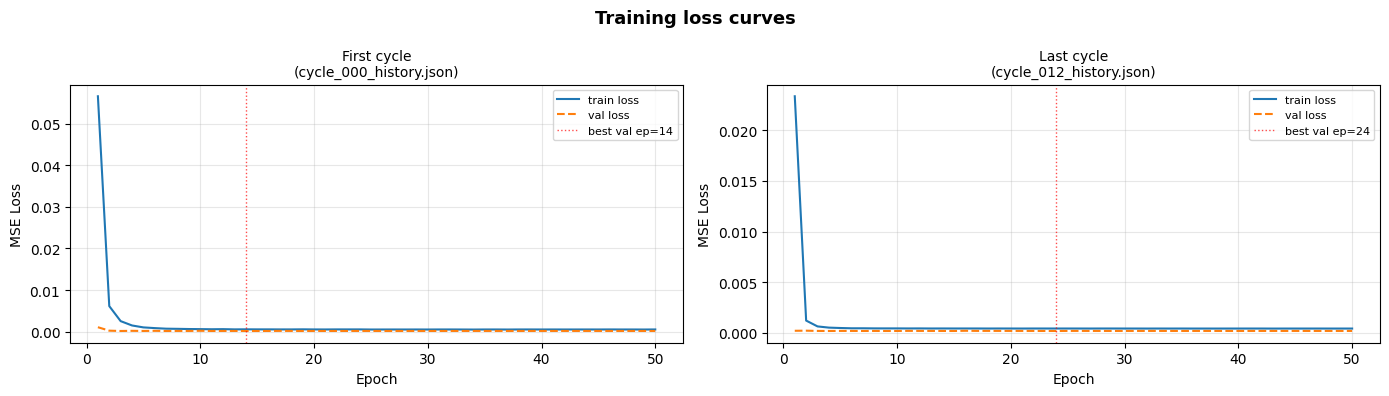

13 history files found.  Showing first + last.


In [5]:
# ── Loss curves — first & last cycle ─────────────────────────────────────────
import glob
import matplotlib.pyplot as plt

_h_files = sorted(glob.glob(os.path.join(WEIGHTS_DIR, 'cycle_*_history.json')))
if not _h_files:
    print('No history files found — run the training cell first.')
else:
    _show   = [_h_files[0], _h_files[-1]] if len(_h_files) > 1 else _h_files
    _labels = ['First cycle', 'Last cycle']  if len(_h_files) > 1 else ['Only cycle']

    fig, axes = plt.subplots(1, len(_show), figsize=(7 * len(_show), 4), squeeze=False)
    fig.suptitle('Training loss curves', fontsize=13, fontweight='bold')

    for ax, h_path, label in zip(axes[0], _show, _labels):
        with open(h_path) as _f:
            _hist = json.load(_f)
        epochs = range(1, len(_hist['loss']) + 1)
        ax.plot(epochs, _hist['loss'],     label='train loss', linewidth=1.5)
        ax.plot(epochs, _hist['val_loss'], label='val loss',   linewidth=1.5, linestyle='--')
        _best_ep = int(np.argmin(_hist['val_loss'])) + 1
        ax.axvline(_best_ep, color='red', linestyle=':', linewidth=1, alpha=0.7,
                   label=f'best val ep={_best_ep}')
        ax.set_title(f'{label}\n({os.path.basename(h_path)})', fontsize=10)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MSE Loss')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    print(f'{len(_h_files)} history files found.  Showing first + last.')


## 5. Inference & Predictions

In [6]:
# ── Load trained cycles ────────────────────────────────────────────────
# (run this cell independently if you skip training above)
with open(os.path.join(WEIGHTS_DIR, 'manifest.json')) as f:
    manifest = json.load(f)

cycles = sorted(manifest['cycles'].items(), key=lambda x: x[1]['cycle_num'])
n_features = len(FEATURE_COLS)
print(f'Loaded manifest: {len(cycles)} cycles')

def load_cycle(cycle_key):
    model = build_model(n_features)
    model.load_weights(os.path.join(WEIGHTS_DIR, f'{cycle_key}.weights.h5'))
    with open(os.path.join(WEIGHTS_DIR, f'{cycle_key}_scaler_X.pkl'), 'rb') as f:
        scaler = pickle.load(f)
    return model, scaler

def predict_return(model, scaler, X_df, idx):
    """Predict 10-day log return path for the WINDOW_SIZE days starting at idx."""
    X_win = X_df.iloc[idx - WINDOW_SIZE:idx]
    X_sc  = scaler.transform(X_win).reshape(1, WINDOW_SIZE, -1)
    return model(X_sc, training=False).numpy().squeeze()

def predict_return_mc(model, scaler, X_df, idx, n_samples=MC_SAMPLES):
    """MC Dropout: returns (mean, lo_95, hi_95) log return estimates."""
    X_win   = X_df.iloc[idx - WINDOW_SIZE:idx]
    X_sc    = scaler.transform(X_win).reshape(1, WINDOW_SIZE, -1)
    X_batch = np.repeat(X_sc, n_samples, axis=0)
    preds   = model(X_batch, training=True).numpy().squeeze(-1)
    m = preds.mean(axis=0)
    s = preds.std(axis=0)
    return m, m - 1.96 * s, m + 1.96 * s

# Pre-compute cycle boundaries
cycle_boundaries = [(info['train_end_idx'], key) for key, info in cycles]
model_cache = {}
dates       = X.index
bt_start_idx = dates.searchsorted(bt_start)
print(f'Backtest start idx: {bt_start_idx} ({dates[bt_start_idx].date()})')

Loaded manifest: 13 cycles
Backtest start idx: 1897 (2015-01-02)


## 5b. Signal Chart

Full backtest time series. Green shading = model predicted ≥ `ENTRY_THRESHOLD` (long entry signal). Orange bands = model retrain dates. Bottom pane shows raw predicted log-return magnitude.


In [7]:
# ── Pre-compute OOS predictions ───────────────────────────────────────────────
# Cache stores the config fingerprint it was built with. If the model config
# changes (window/horizon/features), the cache is automatically invalidated.
PRED_CACHE  = os.path.join(WEIGHTS_DIR, 'pred_cache.pkl')
FORCE_REGEN = False   # set True to force a rebuild regardless of cache state

_loaded = False
if not FORCE_REGEN and os.path.isfile(PRED_CACHE):
    with open(PRED_CACHE, 'rb') as f:
        _cache = pickle.load(f)
    if (isinstance(_cache, tuple) and len(_cache) == 3
            and isinstance(_cache[0], pd.Series)
            and isinstance(_cache[0].index, pd.DatetimeIndex)):
        pred_series, retrain_dates, _cached_fp = _cache
        if _cached_fp != current_fp:
            print(f'⚠️  Pred cache config mismatch (cached={_cached_fp}, current={current_fp}) — rebuilding')
        else:
            _expected_start = pd.Timestamp(BACKTEST_START) + pd.Timedelta(days=60)
            if pred_series.index[0] <= _expected_start:
                print(f'✅ Loaded cache: {len(pred_series)} predictions  [fp={_cached_fp}]')
                print(f'   Range: {pred_series.index[0].date()} → {pred_series.index[-1].date()}')
                _loaded = True
            else:
                print(f'⚠️  Cache starts at {pred_series.index[0].date()} — stale, rebuilding')
    else:
        print('⚠️  Old cache format — rebuilding')

if not _loaded:
    if os.path.isfile(PRED_CACHE):
        os.remove(PRED_CACHE)

    from collections import defaultdict

    retrain_dates = []
    _preds_dict   = {}

    # Pass 1: assign each backtest idx to its cycle
    cycle_for_idx = {}
    cycle_i = 0
    cur_key = None
    for i in range(bt_start_idx, len(dates)):
        if cycle_i < len(cycle_boundaries) and i >= cycle_boundaries[cycle_i][0]:
            new_key = cycle_boundaries[cycle_i][1]
            if new_key != cur_key:
                retrain_dates.append(dates[i])
                cur_key = new_key
            cycle_i += 1
        if cur_key is None or i < WINDOW_SIZE:
            continue
        cycle_for_idx[i] = cur_key

    # Pass 2: batch predict per cycle
    cycle_groups = defaultdict(list)
    for idx, ck in cycle_for_idx.items():
        cycle_groups[ck].append(idx)

    for ck, idxs in sorted(cycle_groups.items()):
        mdl, scl = load_cycle(ck)
        X_sc  = scl.transform(X).astype('float32')
        Xw    = np.stack([X_sc[i - WINDOW_SIZE:i] for i in idxs])
        preds = mdl(Xw, training=False).numpy().reshape(-1)
        for idx, p in zip(idxs, preds):
            _preds_dict[dates[idx]] = float(p)
        print(f'  {ck}: {len(idxs):,} preds  {dates[idxs[0]].date()} → {dates[idxs[-1]].date()}  ✓')

    pred_series = pd.Series(_preds_dict, name='pred').sort_index()

    # Store tuple of (predictions, retrain_dates, config_fingerprint)
    with open(PRED_CACHE, 'wb') as f:
        pickle.dump((pred_series, retrain_dates, current_fp), f)
    print(f'✅ {len(pred_series)} predictions cached  [fp={current_fp}]')
    print(f'   Range: {pred_series.index[0].date()} → {pred_series.index[-1].date()}')

print(f'Retrains: {len(retrain_dates)}  |  {[str(d.date()) for d in retrain_dates]}')


  cycle_000: 252 preds  2015-01-02 → 2015-12-24  ✓
  cycle_001: 252 preds  2015-12-28 → 2016-12-19  ✓
  cycle_002: 252 preds  2016-12-20 → 2017-12-12  ✓
  cycle_003: 252 preds  2017-12-13 → 2018-12-07  ✓
  cycle_004: 252 preds  2018-12-10 → 2019-12-04  ✓
  cycle_005: 252 preds  2019-12-05 → 2020-11-30  ✓
  cycle_006: 252 preds  2020-12-01 → 2021-11-23  ✓
  cycle_007: 252 preds  2021-11-24 → 2022-11-14  ✓
  cycle_008: 252 preds  2022-11-15 → 2023-11-07  ✓
  cycle_009: 252 preds  2023-11-08 → 2024-11-01  ✓
  cycle_010: 252 preds  2024-11-04 → 2025-10-29  ✓
  cycle_011: 97 preds  2025-10-30 → 2026-03-18  ✓
  cycle_012: 1 preds  2026-03-19 → 2026-03-19  ✓
✅ 2870 predictions cached  [fp=7c68048fde48]
   Range: 2015-01-02 → 2026-03-19
Retrains: 13  |  ['2015-01-02', '2015-12-28', '2016-12-20', '2017-12-13', '2018-12-10', '2019-12-05', '2020-12-01', '2021-11-24', '2022-11-15', '2023-11-08', '2024-11-04', '2025-10-30', '2026-03-19']


In [ ]:

# ── Signal chart + Strategy vs B&H — interactive threshold slider ─────────────
import ipywidgets as widgets
from IPython.display import display, clear_output

ENTRY_THRESHOLD = 0.0135

def ts(series, col='value'):
    return pd.DataFrame({'time': series.index.strftime('%Y-%m-%d'), col: series.values})

price_bt   = df['close'].loc[df.index >= pd.Timestamp(BACKTEST_START)]
pred_s     = pred_series.reindex(price_bt.index)
_daily_ret = np.log(price_bt / price_bt.shift(1)).fillna(0)

# static retrain bands
retrain_pos = pd.Series(0, index=price_bt.index)
for _rd in retrain_dates:
    _m = (price_bt.index >= _rd) & (price_bt.index < _rd + pd.offsets.BDay(3))
    retrain_pos[_m] = 1
retrain_shade = pd.DataFrame({'time': price_bt.index.strftime('%Y-%m-%d'), 'position': retrain_pos.values})

_nonzero = pred_s.dropna()
_thr_min = float(np.percentile(_nonzero, 3))
_thr_max = float(np.percentile(_nonzero, 97))

def _render(thr):
    sig    = (pred_s >= thr).fillna(False).astype(int)
    pos    = sig.shift(1).fillna(0)
    sr     = _daily_ret * pos
    bh_cum = _daily_ret.cumsum().apply(np.exp)
    st_cum = sr.cumsum().apply(np.exp)
    sh_bh  = (_daily_ret.mean() / (_daily_ret.std() + 1e-9)) * 252**0.5
    sh_st  = (sr.mean()         / (sr.std()         + 1e-9)) * 252**0.5
    mdd_st = float((st_cum / st_cum.cummax() - 1).min() * 100)
    mdd_bh = float((bh_cum / bh_cum.cummax() - 1).min() * 100)
    pct    = sig.mean() * 100
    print(f'Strategy: {st_cum.iloc[-1]:.2f}x  Sharpe={sh_st:.2f}  MDD={mdd_st:.1f}%  in-market={pct:.1f}%'
          f'  |  B&H: {bh_cum.iloc[-1]:.2f}x  Sharpe={sh_bh:.2f}  MDD={mdd_bh:.1f}%')
    shade_long = pd.DataFrame({'time': price_bt.index.strftime('%Y-%m-%d'), 'position': sig.values})
    p1 = Chart(height=360, watermark='CAC40 TR')
    p1.line(ts(price_bt), name='CAC40 TR', color='#4169E1')
    p1.shade(shade_long,    color='#00CC96', opacity=0.15)
    p1.shade(retrain_shade, color='#FF9500', opacity=0.40)
    p2 = Chart(height=140, watermark='Predicted 5d max-return')
    p2.baseline(ts(pred_s.fillna(0)), base_value=0)
    p2.price_line(thr, title=f'thr={thr:.4f}', color='#00CC96')
    p3 = Chart(height=180, watermark='Strategy vs B&H')
    p3.line(ts(bh_cum), name='B&H',      color='#4169E1')
    p3.line(ts(st_cum), name='Strategy', color='#00CC96')
    Dashboard(
        panes=[p1, p2, p3],
        titles=['CAC40 TR — TKAN v3', 'Predicted 5d max-return', 'Strategy vs B&H'],
    ).show()

out    = widgets.Output()
slider = widgets.FloatSlider(
    value=ENTRY_THRESHOLD, min=round(_thr_min, 4), max=round(_thr_max, 4), step=0.0005,
    description='Threshold:', readout_format='.4f',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='700px'),
)

def _out_render(thr):
    with out:
        clear_output(wait=True)
        _render(thr)

slider.observe(lambda c: _out_render(c['new']), names='value')
_out_render(slider.value)
display(widgets.VBox([slider, out]))


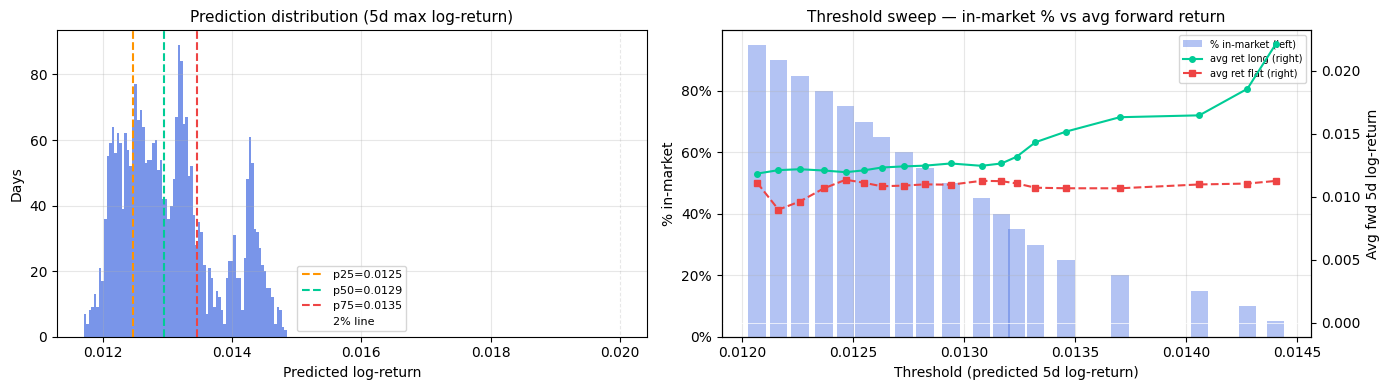


 Threshold   In-mkt %    Avg long    Avg flat   L/F ratio
---------------------------------------------------------
    0.0121      95.0%      0.0118      0.0111        1.07
    0.0122      90.0%      0.0121      0.0090        1.35
    0.0123      85.0%      0.0122      0.0096        1.27
    0.0124      80.0%      0.0121      0.0107        1.13
    0.0125      75.0%      0.0120      0.0114        1.05
    0.0125      70.0%      0.0121      0.0111        1.09
    0.0126      65.0%      0.0123      0.0108        1.14
    0.0127      60.0%      0.0124      0.0109        1.14
    0.0128      55.0%      0.0125      0.0110        1.14
    0.0129      50.0%      0.0126      0.0110        1.15
    0.0131      45.0%      0.0125      0.0113        1.11
    0.0132      40.0%      0.0126      0.0112        1.12
    0.0132      35.0%      0.0132      0.0111        1.19
    0.0133      30.0%      0.0143      0.0107        1.34
    0.0135      25.0%      0.0152      0.0107        1.42
    0.0137   

In [9]:
# ── Threshold sensitivity analysis ──────────────────────────────────────────
# For each candidate threshold: % in-market, avg fwd 5d return when long vs flat,
# and long/flat return ratio. Helps pick the right entry cutoff.

import matplotlib.ticker as mtick

_pred = pred_s.dropna()
_fwd  = y.reindex(_pred.index)          # actual 5d log-return (ground truth)

# ── 1. Distribution histogram ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.hist(_pred.values, bins=80, color='#4169E1', alpha=0.7, edgecolor='none')
for q, col, lbl in [(0.25, '#FF9500', 'p25'), (0.50, '#00CC96', 'p50'), (0.75, '#EE4444', 'p75')]:
    ax.axvline(_pred.quantile(q), color=col, linewidth=1.5, linestyle='--', label=f'{lbl}={_pred.quantile(q):.4f}')
ax.axvline(0.02, color='white', linewidth=1.5, linestyle=':', label='2% line')
ax.set_title('Prediction distribution (5d max log-return)', fontsize=11)
ax.set_xlabel('Predicted log-return')
ax.set_ylabel('Days')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── 2. Threshold sweep ────────────────────────────────────────────────────────
_candidates = np.percentile(_pred.values, np.arange(5, 96, 5))   # p5 → p95

rows = []
for thr in _candidates:
    long_mask = _pred >= thr
    flat_mask = ~long_mask
    pct_long  = long_mask.mean() * 100
    avg_long  = _fwd[long_mask].mean()  if long_mask.any()  else np.nan
    avg_flat  = _fwd[flat_mask].mean()  if flat_mask.any()  else np.nan
    ratio     = avg_long / avg_flat if (avg_flat and avg_flat > 0) else np.nan
    rows.append({'threshold': thr, 'in_market_%': pct_long,
                 'avg_ret_long': avg_long, 'avg_ret_flat': avg_flat, 'long/flat': ratio})

_sweep = pd.DataFrame(rows)

ax2 = axes[1]
c1, c2 = '#00CC96', '#EE4444'
ax2.bar(_sweep['threshold'], _sweep['in_market_%'], width=_sweep['threshold'].diff().median() * 0.8,
        align='center', color='#4169E1', alpha=0.4, label='% in-market (left)')
ax2.set_ylabel('% in-market'); ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2b = ax2.twinx()
ax2b.plot(_sweep['threshold'], _sweep['avg_ret_long'], color=c1, marker='o', ms=4, label='avg ret long (right)')
ax2b.plot(_sweep['threshold'], _sweep['avg_ret_flat'], color=c2, marker='s', ms=4, label='avg ret flat (right)', linestyle='--')
ax2b.set_ylabel('Avg fwd 5d log-return')
ax2b.axhline(0, color='white', linewidth=0.5)
lines1, lbl1 = ax2.get_legend_handles_labels()
lines2, lbl2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, lbl1 + lbl2, fontsize=7, loc='upper right')
ax2.set_title('Threshold sweep — in-market % vs avg forward return', fontsize=11)
ax2.set_xlabel('Threshold (predicted 5d log-return)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Print table ───────────────────────────────────────────────────────────────
print(f'\n{"Threshold":>10}  {"In-mkt %":>9}  {"Avg long":>10}  {"Avg flat":>10}  {"L/F ratio":>10}')
print('-' * 57)
for _, r in _sweep.iterrows():
    print(f'{r["threshold"]:>10.4f}  {r["in_market_%"]:>8.1f}%  '
          f'{r["avg_ret_long"]:>10.4f}  {r["avg_ret_flat"]:>10.4f}  '
          f'{r["long/flat"]:>10.2f}')
